# GMM Analysis on English Romance Movies

Unlike K-Means, GMM doesn't give you hard cluster centers but rather distributions. I can analyze the means and covariances of these distributions, to see if i get different clusters. Since GMM provides probabilities, you can analyze the confidence of each cluster assignment. I can Compare the clusters obtained from GMM with those from K-Means. See if GMM captures more nuanced patterns, especially in cases where the data might not be well-separated.

### Step 1: Prepare the Data
I'll group the data by movie and segment and reshape the colors as you've done before.

In [17]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML 
import matplotlib.colors as mcolors
import math
from collections import Counter
from sklearn.mixture import GaussianMixture

In [3]:
# Path to the directory containing the CSV files
directory_path = '/Users/rsudhir/Documents/GitHub/Data-Science-Project---Colors-Of-Romance/English-Analysis/English-Movie-CSVs'

# List to hold each DataFrame
dfs = []

# Loop through the files in the directory and load each CSV
for i in range(1, 26):
    file_path = os.path.join(directory_path, f'{i}.csv')
    df = pd.read_csv(file_path)
    # Drop columns with NaN values
    df = df.drop(columns=['color_10_r', 'color_10_g', 'color_10_b'])
    
    # Add a column to indicate which movie the data is from
    df['movie_id'] = i
    
    dfs.append(df)

# Combine all DataFrames into a single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

# Display the combined DataFrame to ensure it looks correct
display(combined_df.head())

,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_r,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id
0,output_0000001.png,94,76,59,210,190,185,28,24,21,...,58,26,24,169,174,174,163,160,165,1
1,output_0000002.png,38,36,28,191,177,178,129,114,101,...,164,132,118,156,148,156,100,88,100,1
2,output_0000003.png,126,109,90,28,24,19,196,180,163,...,170,168,165,178,180,163,71,63,34,1
3,output_0000004.png,41,32,30,94,81,72,105,100,90,...,155,156,154,83,89,101,152,148,156,1
4,output_0000005.png,32,27,26,196,174,161,121,93,80,...,119,130,150,148,148,140,73,77,96,1


In [4]:
# Define the number of segments
num_segments = 5

# Loop through each movie and create a segment ID
combined_df['segment_id'] = combined_df.groupby('movie_id').cumcount() // (combined_df.groupby('movie_id')['frame_path'].transform('count') // num_segments)

### Step 2: Determine the Optimal Number of Components for Each Segment
Use to determine the optimal number of components (clusters) for each segment.

### Step 3: Fit GMM on Colors for Each Segment
Fit a GMM on the color data for each segment based on the optimal number of clusters.

In [7]:
# Create a list to hold all cluster centers
all_cluster_centers = []

# Group the data by movie and segment
grouped = combined_df.groupby(['movie_id', 'segment_id'])

for (movie_id, segment_id), group in grouped:
    # Reshape the data to have each color as an individual row
    colors = []
    for i in range(1, 10):  # Looping through the top 9 dominant colors
        colors.append(group[[f'color_{i}_r', f'color_{i}_g', f'color_{i}_b']].dropna().values)

    # Combine all the colors into a single array
    colors_array = np.vstack(colors)

    # Remove duplicate rows if any
    colors_array = np.unique(colors_array, axis=0)

    # Check if there are enough data points to perform clustering
    if len(colors_array) >= 2:  # At least 2 data points for GMM
        # Determine the maximum number of components
        max_components = min(len(colors_array), 15)  # Ensure max_components does not exceed len(colors_array)

        # Use BIC to determine the optimal number of components
        bic = []
        n_components = range(1, max_components + 1)  # Adjust the range based on the available data

        for n in n_components:
            gmm = GaussianMixture(n_components=n, random_state=42)
            gmm.fit(colors_array)
            bic.append(gmm.bic(colors_array))

        # Choose the number of components with the lowest BIC
        optimal_n_components = n_components[bic.index(min(bic))]

        # Fit GMM with the optimal number of components
        gmm = GaussianMixture(n_components=optimal_n_components, random_state=42)
        gmm.fit(colors_array)

        # Store the means (cluster centers) from the GMM
        all_cluster_centers.append(gmm.means_)

    else:
        print(f"Skipping segment {segment_id} of movie {movie_id} due to insufficient data points.")

# Combine all the cluster centers into a single array for further analysis
all_cluster_centers = np.vstack(all_cluster_centers)



### More on BIC

**What BIC Does:**
Penalizes Complexity: If you increase the number of clusters, the likelihood will improve, but BIC adds a penalty for this increased complexity.

**Balances Fit and Simplicity:** 
BIC tries to find a balance where the model is neither too simple (underfitting) nor too complex (overfitting). It often results in fewer clusters than a fixed, higher number like 15.

**When using BIC:**

**Fewer Clusters:**

If BIC suggests fewer clusters, the cluster centers might represent a broader range of colors, potentially leading to more muted, less saturated colors because each cluster center is an average of a wider range of colors.

**More Clusters:** 

If BIC suggests more clusters, the centers would likely be more saturated, similar to what you observed with K-Means.


### Visualizing the centres as before

In [9]:
# Convert RGB values to HEX and HSV
hex_colors = []
hsv_colors = []

for r, g, b in all_cluster_centers:
    hex_color = mcolors.to_hex([r/255, g/255, b/255])
    hsv_color = mcolors.rgb_to_hsv([r/255, g/255, b/255])
    
    hex_colors.append(hex_color)
    hsv_colors.append(hsv_color)

# Sort colors by HSV values (primarily by hue)
sorted_indices = sorted(range(len(hsv_colors)), key=lambda i: (hsv_colors[i][0], hsv_colors[i][1], hsv_colors[i][2]))
sorted_hex_colors = [hex_colors[i] for i in sorted_indices]

# Set the number of columns in the grid
num_columns = 20 

# Calculate the number of rows needed
num_rows = math.ceil(len(sorted_hex_colors) / num_columns)

# Adjust the HTML table to be more responsive
html_table = '<table style="border-collapse: collapse; width:100%;">'
for i in range(num_rows):
    html_table += '<tr>'
    for j in range(num_columns):
        index = i * num_columns + j
        if index < len(sorted_hex_colors):
            hex_color = sorted_hex_colors[index]
            html_table += f'<td style="background-color:{hex_color}; width:5%; height:25px; border: 1px solid #ccc;"></td>'
            html_table += f'<td style="padding: 5px;">{hex_color}</td>'
    html_table += '</tr>'
html_table += '</table>'


# Display the HTML table
display(HTML(html_table))

# Colors are displayed Left to Right, Top to Bottom.


,#040404,,#040404,,#040404,,#0c0c0c,,#847c7c,,#dfd1d1,,#948484,,#3d3535,,#2f2121,,#3b2929,,#060404,,#060404,,#060404,,#060404,,#080404,,#080404,,#8b6969,,#615656,,#a19191,,#3d3434
,#986160,,#5c5958,,#8c8888,,#907b7b,,#9e9190,,#9b7674,,#9b9494,,#a47e7c,,#817a7a,,#1d1919,,#221716,,#816461,,#91625d,,#6c6565,,#8d4e47,,#777474,,#a08e8c,,#1f1716,,#4c1710,,#a5847f
,#130f0f,,#715d5b,,#130c0b,,#4b4240,,#85625c,,#a45447,,#a67f78,,#2b1f1d,,#742214,,#b0a5a4,,#7d4137,,#7b6f6c,,#9d695f,,#9a6055,,#665b59,,#382927,,#a25546,,#523b37,,#3e3533,,#60413b
,#1a1818,,#9e736a,,#211816,,#a37f77,,#4f2e27,,#975343,,#afa5a3,,#a8472f,,#afa4a1,,#685c5a,,#ac6c5c,,#2a1e1b,,#b38b81,,#6a3e32,,#8d7872,,#523a33,,#796e6b,,#af5941,,#a97263,,#98503a
,#241611,,#47332d,,#251a17,,#5a5554,,#828181,,#a55a43,,#a24b30,,#4b3b36,,#99817a,,#8b5544,,#a55135,,#9a6451,,#644f47,,#251c19,,#62483f,,#544b48,,#928581,,#1f1613,,#4c2b1e,,#412e28
,#886254,,#8b5c4b,,#845544,,#5c443b,,#9f6954,,#704637,,#574741,,#a86850,,#994c2e,,#b1765f,,#1e1917,,#806256,,#865e4e,,#271e1b,,#45342d,,#946d5d,,#986a57,,#887a74,,#7b6055,,#6d615c
,#57443c,,#72574c,,#2b1d17,,#6c5349,,#54443d,,#b08877,,#8b6453,,#736c69,,#9f7867,,#31231d,,#805440,,#21130c,,#3d2b23,,#58392b,,#98644c,,#5e3d2e,,#925e46,,#241a15,,#a7735a,,#78665d
,#aa5a34,,#8d6a59,,#3e281d,,#231c19,,#8c6653,,#543d32,,#9d6d55,,#b55526,,#211e1c,,#977362,,#352c27,,#9e887d,,#1b1715,,#7a6053,,#36312f,,#141210,,#2c221d,,#947565,,#8a827e,,#7d5d4d
,#433832,,#947a6d,,#8d7466,,#886553,,#7a655a,,#543727,,#a68c7e,,#452d21,,#703a1d,,#a7755a,,#533626,,#96512b,,#5a4134,,#211e1c,,#62371f,,#57524f,,#281b14,,#55473f,,#886a58,,#402616
,#3e291d,,#7d553e,,#8c6a55,,#916d59,,#75645a,,#6b4b38,,#7a5945,,#453023,,#472714,,#4b372a,,#8a7162,,#6c625c,,#827065,,#5e4b41,,#c6c0bd,,#987057,,#3a271b,,#b5a59b,,#563a29,,#1f1712
,#33261e,,#996e53,,#211b17,,#2d1f17,,#8a7e77,,#504036,,#534135,,#b97245,,#64584f,,#503f34,,#95735d,,#342c26,,#865f45,,#a85b29,,#ac7c5c,,#0c0907,,#483a31,,#8a6852,,#b9a395,,#624e40


### Similarly Lets Percentile these Colors

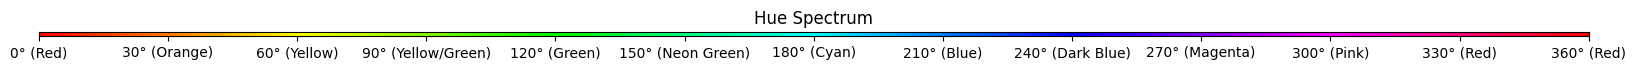

In [10]:
# Generate a spectrum of hues
hues = np.linspace(0, 1, 360)  # 360 values corresponding to hue angles
saturation = np.ones_like(hues)
value = np.ones_like(hues)

# Convert HSV to RGB
hsv_colors = np.stack([hues, saturation, value], axis=1)
rgb_colors = mcolors.hsv_to_rgb(hsv_colors)

# Plot the spectrum
plt.figure(figsize=(20, 2))
plt.imshow([rgb_colors], extent=[0, 360, 0, 1])
plt.yticks([])
plt.xticks(np.arange(0, 361, 30), labels=[
    "0° (Red)", "30° (Orange)", "60° (Yellow)", "90° (Yellow/Green)",
    "120° (Green)", "150° (Neon Green)", "180° (Cyan)", "210° (Blue)",
    "240° (Dark Blue)", "270° (Magenta)", "300° (Pink)", "330° (Red)", "360° (Red)"
])
plt.title("Hue Spectrum")
plt.show()


In [11]:
def classify_color_by_tone(hsv):
    hue = hsv[0] * 360  # Convert hue from [0, 1] to [0, 360]
    
    if hue < 30 or hue >= 330:
        return 'red'
    elif 30 <= hue < 60:
        return 'orange'
    elif 60 <= hue < 90:
        return 'yellow'
    elif 90 <= hue < 120:
        return 'yellow/green'
    elif 120 <= hue < 150:
        return 'green'
    elif 150 <= hue < 180:
        return 'neon green'
    elif 180 <= hue < 210:
        return 'cyan'
    elif 210 <= hue < 240:
        return 'blue'
    elif 240 <= hue < 270:
        return 'dark blue'
    elif 270 <= hue < 300:
        return 'magenta'
    elif 300 <= hue < 330:
        return 'pink'
    else:
        return 'unknown'

# Convert the RGB cluster centers to HSV and classify them by tone
color_tones = [classify_color_by_tone(mcolors.rgb_to_hsv([r/255, g/255, b/255])) for r, g, b in all_cluster_centers]

# Count the occurrences of each tone
tone_counts = Counter(color_tones)

# Calculate the percentage of each tone
total_colors = len(all_cluster_centers)
tone_percentages = {tone: (count / total_colors) * 100 for tone, count in tone_counts.items()}

# Sanity check: Ensure total counts match the number of colors
total_count = sum(tone_counts.values())
if total_count == total_colors:
    print("All colors are accounted for.")
    print("total_colors: "+str(total_count))
else:
    print(f"Warning: Mismatch in total counts. Expected {total_colors}, but got {total_count}.")

# Check for any "unknown" classifications
if 'unknown' in tone_counts:
    print(f"Warning: {tone_counts['unknown']} colors are classified as 'unknown'.")
else:
    print("No colors are classified as 'unknown'.")

# Print a sample of classified colors
print("Sample of classified colors:")
sample_size = min(10, len(all_cluster_centers))  # Adjust sample size as needed
for i in range(sample_size):
    r, g, b = all_cluster_centers[i]
    hsv = mcolors.rgb_to_hsv([r/255, g/255, b/255])
    tone = classify_color_by_tone(hsv)
    print(f"Color RGB({r}, {g}, {b}) -> HSV({hsv[0]*360:.2f}°, {hsv[1]:.2f}, {hsv[2]:.2f}) -> Tone: {tone}")

# Sort tones by percentage in descending order
sorted_tones = sorted(tone_percentages.items(), key=lambda x: x[1], reverse=True)

# Display the summary of counts and percentages in sorted order
print("\nSummary of tone counts and percentages (sorted by percentage):")
for tone, percentage in sorted_tones:
    count = tone_counts[tone]
    print(f"{tone.capitalize()}: {count} colors ({percentage:.2f}%)")


All colors are accounted for.
total_colors: 1051
No colors are classified as 'unknown'.
Sample of classified colors:
Color RGB(135.5337823502202, 133.85895478206447, 141.26243121622778) -> HSV(253.57°, 0.05, 0.55) -> Tone: dark blue
Color RGB(81.3514090230737, 74.16067954585745, 59.80571101097931) -> HSV(39.98°, 0.26, 0.32) -> Tone: orange
Color RGB(30.112393803506222, 26.65296499426099, 22.622832399060265) -> HSV(32.29°, 0.25, 0.12) -> Tone: orange
Color RGB(152.20601750800424, 153.72312797571138, 155.06491699611811) -> HSV(208.16°, 0.02, 0.61) -> Tone: cyan
Color RGB(202.1520950256117, 193.67161455899918, 184.6877183514234) -> HSV(30.86°, 0.09, 0.79) -> Tone: orange
Color RGB(100.09354176139723, 98.45276067851947, 99.9894870100772) -> HSV(303.81°, 0.02, 0.39) -> Tone: pink
Color RGB(147.8827041071263, 117.15746914371825, 101.26391444717548) -> HSV(20.46°, 0.32, 0.58) -> Tone: red
Color RGB(165.79774009498487, 126.57350867143154, 120.08584738317428) -> HSV(8.52°, 0.28, 0.65) -> Tone: 

### Final GMM on all the cluster centers

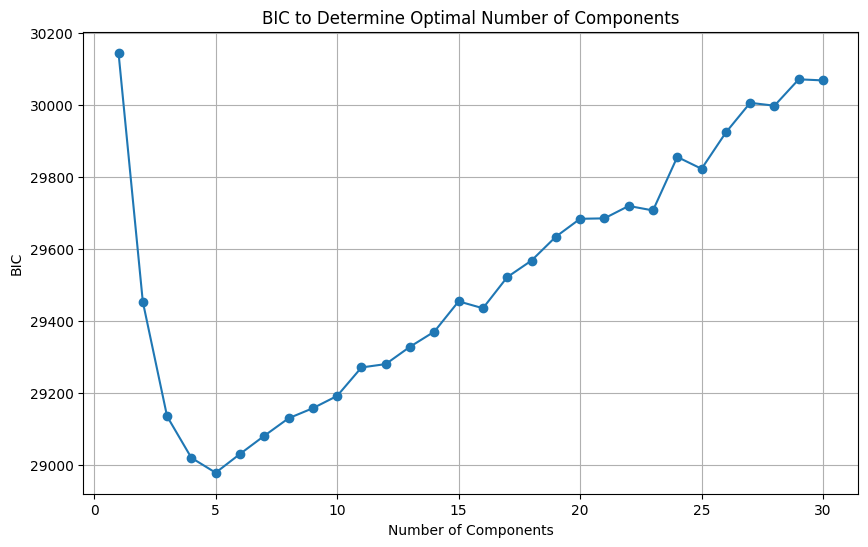

In [12]:
# Use BIC to determine the optimal number of components
bic = []
n_components = range(1, 31)  # making it 30 to see how close it is to k_means clustering

for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(all_cluster_centers)
    bic.append(gmm.bic(all_cluster_centers))

# Plot BIC to visualize the optimal number of clusters
plt.figure(figsize=(10, 6))
plt.plot(n_components, bic, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('BIC')
plt.title('BIC to Determine Optimal Number of Components')
plt.grid(True)
plt.show()

# Choose the number of components with the lowest BIC
optimal_n_components = n_components[bic.index(min(bic))]


In [15]:
# Fit the GMM with the optimal number of components
final_gmm = GaussianMixture(n_components=30, random_state=42) # Tried 5 here but its color averages are really dull, not capturing 
# the granularity of color so increasing to 30
final_gmm.fit(all_cluster_centers)

# Get the final cluster centers (means) and other relevant details
final_means = final_gmm.means_

In [16]:
# Convert RGB values to HEX
final_hex_colors = [mcolors.to_hex([r/255, g/255, b/255]) for r, g, b in final_means]

# Sort the final colors by hue to make them more visually organized (optional)
hsv_colors = [mcolors.rgb_to_hsv([r/255, g/255, b/255]) for r, g, b in final_means]
sorted_indices = sorted(range(len(hsv_colors)), key=lambda i: (hsv_colors[i][0], hsv_colors[i][1], hsv_colors[i][2]))
sorted_final_hex_colors = [final_hex_colors[i] for i in sorted_indices]

# Create an HTML table with a grid layout to display the colors
num_columns = 5  # Adjust the number of columns for the display
num_rows = math.ceil(len(sorted_final_hex_colors) / num_columns)

html_table = '<table style="border-collapse: collapse;">'
for i in range(num_rows):
    html_table += '<tr>'
    for j in range(num_columns):
        index = i * num_columns + j
        if index < len(sorted_final_hex_colors):
            hex_color = sorted_final_hex_colors[index]
            html_table += f'<td style="background-color:{hex_color}; width:50px; height:25px; border: 1px solid #ccc;"></td>'
            html_table += f'<td style="padding: 5px;">{hex_color}</td>'
    html_table += '</tr>'
html_table += '</table>'

# Display the HTML table with the final colors
display(HTML(html_table))


,#070707,,#9e5236,,#825e4a,,#5b3b28,,#483b32
,#734c30,,#a47e62,,#8d6f59,,#5b4e41,,#34291f
,#1e1915,,#f6b44e,,#968872,,#beb5a4,,#6f6c57
,#767672,,#cccab1,,#5a5b56,,#8d8f8a,,#a6aaa1
,#424743,,#97a39c,,#c1dadc,,#d8dcde,,#435862
,#0d2539,,#93b1cb,,#94999d,,#65809b,,#342dc6
